# Homework 4: The Bootstrap

BEE 4850/5850, Fall 2025

**Name**: Luan Brito

**ID**: ls2236

> **Due Date**
>
> Friday, 3/28/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practice simulation-based
uncertainty quantification, focusing on the bootstrap.

-   Problem 1 asks you to use the non-parametric bootstrap to estimate
    uncertainty in a Poisson regression model.
-   Problem 2 asks you to use the bootstrap (through resampling
    residuals) to estimate uncertainty in a semi-empirical sea-level
    rise model.
-   Problem 3 (only required for students in BEE 5850) asks you to use a
    moving block bootstrap to estimate the sampling distribution of the
    median of extreme water level data.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [1]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Projects/bee_5850/hw04-britols`


The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [2]:
using Random # random number generation and seed-setting
using DataFrames # tabular data structure
using DataFramesMeta # API which can simplify chains of DataFrames transformations
using CSV # reads/writes .csv files
using Distributions # interface to work with probability distributions
using Plots # plotting library
using StatsBase # statistical quantities like mean, median, etc
using StatsPlots # some additional statistical plotting tools
using Optim # optimization tools
using Dates

In [3]:
#Pkg.add("KernelDensity")
using KernelDensity

## Problems

### Scoring

-   Problem 1 is worth 10 points;
-   Problem 2 is worth 10 points;
-   Problem 3 is worth 5 points;

### Problem 1

Revisit the salamander model from [Homework
2](https://viveks.me/simulation-data-analysis/hw/hw02.html), using
percent groundcover as a predictor in the Poisson regression. Use the
non-parametric bootstrap to estimate bias and confidence intervals for
the model parameters.

**In this problem**:

-   Load the data from `data/salamanders.csv`.
-   Fit a Poisson regression model for salamander counts using the
    percentage of ground cover.
-   Use 1,000 non-parametric bootstrap samples to obtain estimates of
    bias and the 90% confidence interval for the intercept and
    coefficient in the Poisson regression.

**Answer:**

MLE estimated parameters are **intercept = 1.159** and **coefficient = 0.429**

Estimate bias is 0.065 for the intercept and 0.077 for the coefficient

Bias corrected bootstrap 90% CI are **intercept = [0.715,1.495]** and **coefficient = [0.164,0.830]**

In [4]:
#Load data
dat = CSV.read(joinpath("data", "salamanders.csv"), DataFrame, delim=";");

In [5]:
#Define functions

function salamander_pcover(p, counts, pctcover) 
    a, b = p
    λ = exp.(a * pctcover .+ b)
    ll = sum(logpdf.(Poisson.(λ), counts))
    return ll
end

salamander_pcover (generic function with 1 method)

In [6]:
#Estimate parameters using MLE

stdz(x) = (x .- mean(x)) / std(x)

x = stdz(dat.PCTCOVER);
y = dat.SALAMAN;
lb = [-5.0, -2.0];
ub = [5.0, 2.0];
p0 = [0.0, 0.0];

result = optimize(p -> -salamander_pcover(p, y, x), lb, ub, p0)
pcover_mle = result.minimizer
@show pcover_mle;

pcover_mle = [1.159506132143577, 0.4295112909445846]


MLE estimated parameters are **intercept = 1.159** and **coefficient = 0.429**

In [7]:
#Run bootstrap simulations
Random.seed!(100);

n_bootstrap = 1_000
N_sample = x.size[1]
params_boot = zeros(length(pcover_mle),n_bootstrap)
for i = 1:n_bootstrap
    idx = sample(1:N_sample,N_sample;replace=true)
    x_boot = x[idx] 
    y_boot = y[idx]
    result = optimize(p -> -salamander_pcover(p, y_boot, x_boot), lb, ub, p0)
    params_boot[:,i] = result.minimizer
end

mean(params_boot; dims=2)

2×1 Matrix{Float64}:
 1.1920875066292869
 0.3909810221088686

Biased bootstrap estimations parameters after 1,000 simulations are **intercept = 1.192** and **coefficient = 0.391**

In [8]:
#Unbiased parameter estimation

np_boot_est = 2 * pcover_mle - mean(params_boot; dims=2)
np_boot_q = mapslices(v -> quantile(v, [0.95, 0.05]), params_boot; dims=2)
np_boot_ci = zeros(2, 2)
for i in eachindex(pcover_mle)
    np_boot_ci[i, :] = 2 * pcover_mle[i] .- np_boot_q[i, :]
end

print(np_boot_est)
print("\n")
print(np_boot_ci)

[1.126924757657867; 0.46804155978030065;;]
[0.7147839306182602 1.4952490447869171; 0.1638739358828062 0.8303306015491259]

Unbiased bootstrap estimations parameters are **intercept = 1.127** [0.715,1.495] (90% C.I.) and **coefficient = 0.468** [0.164,0.830] (90% C.I.)

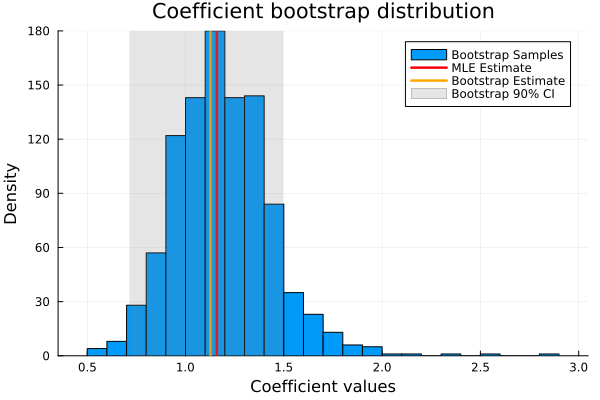

In [9]:
histogram(params_boot[1,:],title="Coefficient bootstrap distribution",label="Bootstrap Samples",xlabel="Coefficient values",ylabel = "Density")
vline!([pcover_mle[1]],color=:red, linewidth = 2.5,label="MLE Estimate")
vline!([np_boot_est[1]],color=:orange, linewidth = 2.5,label="Bootstrap Estimate")
vspan!([np_boot_ci[1,:]],color=:grey, label="Bootstrap 90% CI",alpha=0.2)

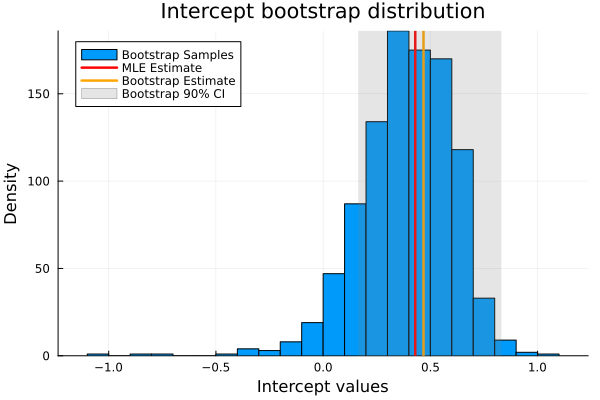

In [10]:
histogram(params_boot[2,:],title="Intercept bootstrap distribution",label="Bootstrap Samples",legend=:topleft,xlabel="Intercept values",ylabel = "Density")
vline!([pcover_mle[2]],color=:red, linewidth = 2.5,label="MLE Estimate")
vline!([np_boot_est[2]],color=:orange, linewidth = 2.5,label="Bootstrap Estimate")
vspan!([np_boot_ci[2,:]],color=:grey, label="Bootstrap 90% CI",alpha=0.2)

### Problem 2

Revisit the sea-level rise model from [Homework
2](https://viveks.me/simulation-data-analysis/hw/hw02.html):

$$\begin{aligned}
\frac{dS}{dt} &= \frac{S_\text{eq} - S}{\tau} \\
S_\text{eq} &= aT + b,
\end{aligned}
$$

where

-   $S(t)$ is the global mean sea level (in mm) at time $t$;
-   $\tau$ is the response time of sea level (in yrs);
-   $S_\text{eq}$ is the equilibrium sea-level (in mm) at temperature
    $T$ (in $^\circ$ C);
-   $a$ is the sensitivity of $S_\text{eq}$ to $T$ (in mm / $^\circ$ C);
-   $b$ is the intercept of $S_\text{eq}$, or the $S_\text{eq}$ when
    $T=0^\circ$ C (in mm).

We would like to quantify uncertainty in the model parameters using the
bootstrap.

**In this problem**:

-   Load the data from the `data/` folder and, following Grinsted et al
    (2010), normalize both datasets to the 1980-1999 mean (subtract that
    mean from the data).
    -   Global mean temperature data from the HadCRUT 5.0.2.0 dataset
        (<https://hadobs.metoffice.gov.uk/hadcrut5/data/HadCRUT.5.0.2.0/download.html>)
        can be found in
        `data/HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv`.
        This data is averaged over the Northern and Southern Hemispheres
        and over the whole year.
    -   Global mean sea level anomalies (relative to the 1990 mean
        global sea level) are in `data/CSIRO_Recons_gmsl_yr_2015.csv`,
        courtesy of CSIRO
        (<https://www.cmar.csiro.au/sealevel/sl_data_cmar.html>). The
        standard deviation of the estimate is also added for each year.
-   Write a function to simulate global mean sea levels under a set of
    model parameters after discretizing the equations above with a
    timestep of $\delta t = 1$ yr. You will need to subset the
    temperature data to the years where you also have sea-level data and
    include an initial sea-level parameter $S_0$. This will be similar
    to the model from Homework 2. Fit this model to the data with AR(1)
    residuals.
-   Use your fitted model and the AR(1) residual process to generate
    1,000 parametric bootstrap samples. Refit the model to each. Plot
    histograms of the bootstrap samples for each parameter. What is the
    90% confidence interval for the sensitivity of sea level to global
    mean temperature?


**Answers:**

- Sensitivity of sea level to global mean temperature (a/τ) estimated by MLE = 3.48 mm/(C yr)
- a/τ estimated by bootstrap sampling = 3.60 mm/(C yr)
- a/τ estimated by bootstrap bias corrected = 3.37 mm/(C yr)
- 90% Confidence interval for the sensitivity of sea level to global mean temperature = [1.86, 4.40] mm/(C yr)

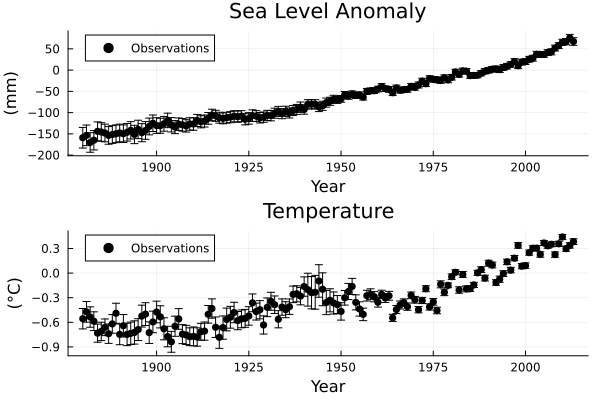

In [11]:
norm_yrs = 1980:1999

sl_dat = DataFrame(CSV.File(joinpath("data",  "CSIRO_Recons_gmsl_yr_2015.csv")))

rename!(sl_dat, [:Year, :GMSLR, :SD]) # rename to make columns easier to work with
sl_dat[!, :Year] .-= 0.5 # shift year to line up with years instead of being half-year 
sl_dat[!, :GMSLR] .-= mean(filter(row -> row.Year ∈ norm_yrs, sl_dat)[!, :GMSLR]) # rescale to be relative to 1880-1900 mean for consistency with temperature anomaly

# load temperature data
temp_dat = DataFrame(CSV.File(joinpath("data", "HadCRUT.5.0.2.0.analysis.summary_series.global.annual.csv")))
rename!(temp_dat, [:Year, :Temp, :Lower, :Upper]) # rename to make columns easier to work with
filter!(row -> row.Year ∈ sl_dat[!, :Year], temp_dat) # reduce to the same years that we have SL data for
temp_normalize = mean(filter(row -> row.Year ∈ norm_yrs, temp_dat)[!, :Temp]) # get renormalization to rescale temperature to 1880-1900 mean
temp_dat[!, :Temp] .-= temp_normalize
temp_dat[!, :Lower] .-= temp_normalize
temp_dat[!, :Upper] .-=  temp_normalize;

sl_plot = scatter(sl_dat[!, :Year], sl_dat[!, :GMSLR], yerr=sl_dat[!, :SD], color=:black, label="Observations", ylabel="(mm)", xlabel="Year", title="Sea Level Anomaly")

temp_plot = scatter(temp_dat[!, :Year], temp_dat[!, :Temp], yerr=(temp_dat[!, :Temp] - temp_dat[!, :Lower], temp_dat[!, :Upper] - temp_dat[!, :Temp]), color=:black, label="Observations", ylabel="(°C)", xlabel="Year", title="Temperature")

plot(sl_plot, temp_plot, layout=(2, 1))

In [12]:
# Definition of important variables:
TIME = temp_dat[!, :Year] #time in years
GMSLR_obs = sl_dat.GMSLR #GMSLR data
GMSLR_obs_error = sl_dat.SD #GMSLR observations error
TEMPERATURE_obs = temp_dat.Temp; #Temperature data

In [13]:
#Define functions

function grinsted_slr(params, temps; Δt=1)
    a, b, τ, S₀ = params
    S = zeros(length(temps)) # initialize storage
    Seq = a * temps .+ b
    S[1] = S₀
    for i = 2:length(S)
        S[i] = S[i-1] +  Δt * (Seq[i] - S[i-1]) / τ
    end
    return S[1:end]
end

function ar1_loglik(params, temp_dat, slr_obs, slr_err, Δt=1.0)
    a, b, τ, S₀, ρ, σ = params 
    slr_sim = grinsted_slr((a, b, τ, S₀), temp_dat; Δt = Δt)
    T = length(slr_sim)
    resid = slr_obs - slr_sim
    ll = 0
    for i = 1:T
        if i == 1
            ll += logpdf(Normal(0, sqrt((σ^2)/(1-ρ^2)+slr_err[i]^2)), resid[i])
        else
            resid_ar = resid[i] + ρ*resid[i-1]
            ll += logpdf(Normal(0, sqrt(σ^2+slr_err[i]^2)), resid_ar)
        end
    end
    return ll
end

ar1_loglik (generic function with 2 methods)

In [14]:
#Modeling residuals with AR(1)
low_bds_ar = [100.0, 100.0, 0.1,  GMSLR_obs[1] - 1.96 * GMSLR_obs_error[1], -0.9999,0]
up_bds_ar = [2000.0, 500.0, 2500.0, GMSLR_obs[1] + 1.96 * GMSLR_obs_error[1], 0.9999,10]
p₀_ar = [1000.0, 200.0, 1500.0, GMSLR_obs[1], 0,5]

mle_optim_ar = optimize(p -> -ar1_loglik(p, TEMPERATURE_obs, GMSLR_obs, GMSLR_obs_error), low_bds_ar, up_bds_ar, p₀_ar)
p_mle_ar = mle_optim_ar.minimizer;

In [15]:
p_mle_ar = vcat(p_mle_ar,p_mle_ar[1]/p_mle_ar[3])

7-element Vector{Float64}:
  471.7814495985444
  311.824725093262
  135.40086916978765
 -157.13089694768541
   -0.5456916710054851
    5.260950319530422e-9
    3.484331027498413

MLE estimated parameters using an AR(1) model for the residuals:
- a = 471.78 (in mm $^\circ\text{C}^{-1}$)
- b = 311.82 mm
- τ = 135.40 years
- S₀ = -157.13 mm
- $\rho$ = -0.55
- σ = 5.26e-9 mm
- a/τ = 3.48 mm/(C yr)

In [16]:
Random.seed!(100);

n_samples = 1_000

GMSLR_boot_ar = zeros(n_samples, length(GMSLR_obs_error))
temp_ar_err =  zeros(n_samples, length(GMSLR_obs_error))
p_mle_boot_ar = zeros(n_samples, length(p_mle_ar))

GMSLR_sim = grinsted_slr(p_mle_ar[1:end-3],TEMPERATURE_obs)

for i = 1:length(GMSLR_obs_error)
    if i == 1
        temp_ar_err[:,i] = rand(Normal(0, sqrt(p_mle_ar[end]^2 / (1 - p_mle_ar[end-1]^2) + GMSLR_obs_error[1]^2)), n_samples)
    else
        temp_ar_err[:,i] = p_mle_ar[end-1] * temp_ar_err[:, i-1] + rand(Normal(0, sqrt(p_mle_ar[end]^2 + GMSLR_obs_error[i]^2)), n_samples)
    end
    GMSLR_boot_ar[:,i] = GMSLR_sim[i] .+ temp_ar_err[:,i]
end

In [17]:
#Parametric bootstrap for parameters estimation uncertainty, each column of p_mle_boot is a collection of fitted values for a single parameter
p_mle_boot_samples_ar1 =  zeros(n_samples, length(p_mle_ar))

for i = 1:n_samples
    mle_optim_ar = optimize(p -> -ar1_loglik(p, TEMPERATURE_obs, GMSLR_boot_ar[i,:], GMSLR_obs_error), low_bds_ar, up_bds_ar, p₀_ar)
    results = mle_optim_ar.minimizer
    results = vcat(results,results[1]/results[3])
    p_mle_boot_samples_ar1[i,:] = results
end

In [75]:
i=1
median(p_mle_boot_samples_ar1[:,1])

470.9731995935011

In [18]:
p_mle_boot_ar1 =  []

for i = 1:length(p_mle_ar)
    boot_out = p_mle_boot_samples_ar1[:,i]
    bias_estimate = mean(boot_out)
    ci_lb, ci_ub = 2 * p_mle_ar[i] .- quantile(boot_out, [0.975, 0.025])
    unbiased_estimate = 2 * p_mle_ar[i]-bias_estimate
    push!(p_mle_boot_ar1,[round(bias_estimate,digits=2),round(unbiased_estimate,digits=2),round(ci_lb,digits=2),round(ci_ub,digits=2)])
end

p_mle_boot_ar1

7-element Vector{Any}:
 [490.38, 453.18, 267.67, 607.91]
 [334.5, 289.15, 123.65, 469.85]
 [145.67, 125.13, 43.19, 205.07]
 [-157.43, -156.83, -165.48, -147.19]
 [0.03, -1.13, -1.29, -0.97]
 [2.77, -2.77, -5.44, 0.0]
 [3.6, 3.37, 1.86, 4.4]

Bootstrap estimated parameters: biased|unbiased [90% C.I.]:
- a = 490.38 | 453.18 [267.67, 607.91] (in mm $^\circ\text{C}^{-1}$)
- b = 334.5 | 289.15 [123.65, 469.85] mm
- τ = 145.67 | 125.13 [43.19, 205.07] years
- S₀ = -157.43 | -156.83 [-165.48, -147.19] mm
- $\rho$ = 0.03 | -1.13 [-1.29, -0.97]
- σ = 2.77 | -2.77 [-5.44, 0] mm
- a/τ = 3.60 | 3.37 [1.86, 4.40] mm/(C yr)

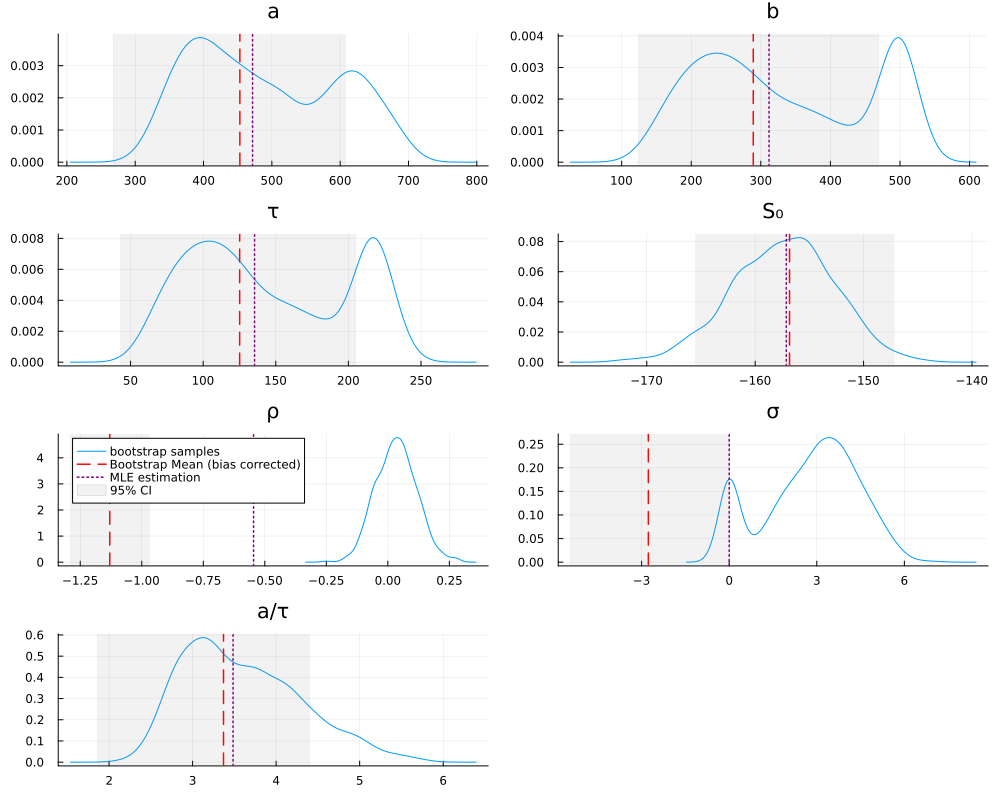

In [19]:
plots = []
titles = ["a","b","τ","S₀","ρ","σ","a/τ"]
legend = zeros(length(titles))
legend[5] = 1
for i = 1:length(p_mle_ar)
    kernel_dist = kde(p_mle_boot_samples_ar1[:,i])
    p = plot(kernel_dist.x,kernel_dist.density,label="bootstrap samples",title=titles[i],legend= (legend[i]==1)) #fillrange=(0,kernel_dist.density),fc =:grey,color =:black, alpha=0.2,label="bootstrap samples")
    vline!(p,[p_mle_boot_ar1[i][2]], linewidth=1.5, color=:red, linestyle=:dash, label="Bootstrap Mean (bias corrected)")
    vline!(p, [p_mle_ar[i]], linewidth=1.5, color=:purple, linestyle=:dot, label="MLE estimation")
    vspan!(p,p_mle_boot_ar1[i][[3,4]], linecolor=:grey, fillcolor=:grey, fillalpha=0.1, label="95% CI")
    push!(plots,p)
    plot!(p, size=(1000, 800))
end
#hspan!(p,[0,minimum(kernel_dist.density)])

plot(plots[1], plots[2], plots[3], plots[4],plots[5],plots[6],plots[7], layout=(4,2))

### Problem 3

Let’s revisit the 2015 Sewell’s Point tide gauge data, which consists of
hourly observations and predicted sea-level based on NOAA’s harmonic
model.

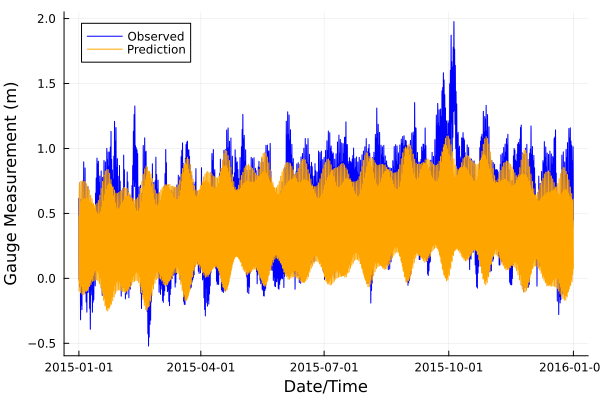

In [20]:
function load_data(fname)
    date_format = "yyyy-mm-dd HH:MM"
    # this uses the DataFramesMeta package -- it's pretty cool
    return @chain fname begin
        CSV.File(; dateformat=date_format)
        DataFrame
        rename(
            "Time (GMT)" => "time", "Predicted (m)" => "harmonic", "Verified (m)" => "gauge"
        )
        @transform :datetime = (Date.(:Date, "yyyy/mm/dd") + Time.(:time))
        select(:datetime, :gauge, :harmonic)
        @transform :weather = :gauge - :harmonic
        @transform :month = (month.(:datetime))
    end
end

dat = load_data("data/norfolk-hourly-surge-2015.csv")

plot(dat.datetime, dat.gauge; ylabel="Gauge Measurement (m)", label="Observed", legend=:topleft, xlabel="Date/Time", color=:blue)
plot!(dat.datetime, dat.harmonic, label="Prediction", color=:orange)

We detrend the data to isolate the weather-induced variability by
subtracting the predictions from the observations; the results
(following the Julia code) are in `dat[:, :weather]`.

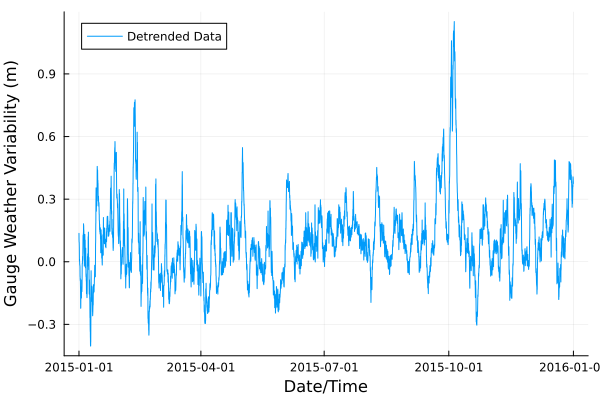

In [21]:
plot(dat.datetime, dat.weather; ylabel="Gauge Weather Variability (m)", label="Detrended Data", linewidth=1, legend=:topleft, xlabel="Date/Time")

We would like to understand the uncertainty in an estimate of the median
sea level.

**In this problem**:

-   Construct 1,000 bootstrap replicates by adding a moving block
    bootstrap replicate from the weather-induced variability series
    (with block length 20) to the harmonic prediction. Use these
    replicates to compute a 90% confidence interval. What is the bias of
    the estimator?
-   Repeat the analysis with block length 50. How does this affect the
    confidence intervals and estimate of bias?
-   Why do you think using different block lengths produced the results
    that they did?

**Answer:**

Estimations using block bootstraping with block length 20
- Bootstrap biased median sea level estimation: 0.513 m
- Estimated median sea level from gauge measurement: 0.508 m
- Bootstrap estimated median sea level bias corrected: 0.503 m
- Bias of the estimator: 0.005
- 90% Confidence interval of median sea level estimation: [0.488,0.517]

Estimations using block bootstraping with block length 50
- Bootstrap biased median sea level estimation: 0.513 m
- Estimated median sea level from gauge measurement: 0.508 m
- Bootstrap estimated median sea level bias corrected: 0.503 m
- Bias of the estimator: 0.005
- 90% Confidence interval of median sea level estimation: [0.482,0.523]

Using a block size of 20 or 50 resulted in the same estimated median sea level and bias, however the 90% confidence interval is wider using blocks of length 50. The histogram of the bootstraped samples medians shows the block bootstrap with length of 50 have, indeed, higher variance than the block length of 20. 

The observed series has strong autocorrelation, in lag 1h the autocorrelation is 0.99 for lag 20h is 0.78 and for lag of 50h is 0.43. This shows that using a block length of 20 is not capturing important oscilations patterns in the original series. The autocorrelation in the bootstrap samples created using the block length of 20 have autocorrelation of pratically zero at lag 20h and beyond, meanwhile the ones from block length of 50 still preserves this signal. Hence, the shorter confidence interval when using block length of 20 might be an artificial result for not accounting for the entire dependence structure of the observations.

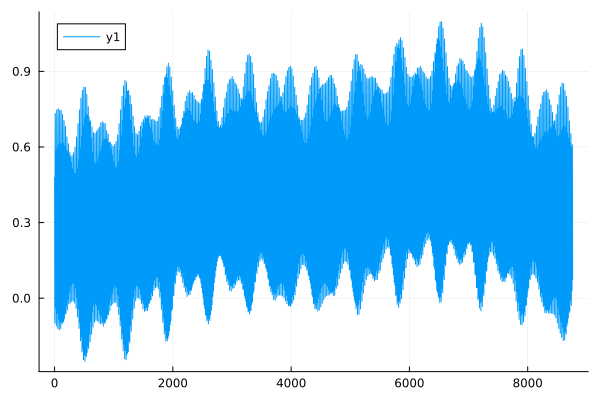

In [22]:
plot(dat.harmonic)

In [61]:
weather = dat.weather
harmonic = dat.harmonic
gauge = dat.gauge

N=length(dat.datetime)
n_boot = 1_000;

In [62]:
function random_block_idx(data,block_size,n_boot=1_000)
    idx = []
    n_blocks = ceil(Int,N/block_size);
    #Create idx to select blocks of data of size block_size
    for i in eachindex(data)
        v = collect(i:1:(i+block_size-1))
        v[ v .> N] = v[ v .> N] .- N
        idx=push!(idx,v)
    end

    boot_samps = zeros((N,n_boot))

    for b in 1:1:n_boot
        idx_samples = rand(1:N,n_blocks)
        boot_idx = reduce(vcat,idx[idx_samples])
        boot_idx = boot_idx[1:N]
        boot_samps[:,b] = weather[boot_idx]
        #boot_samps = push!(boot_samps,harmonic+weather[boot_idx])
    end

    return(boot_samps)
end;

In [63]:
#Draw bootstrap samples
Random.seed!(100);
boot_samps_weather_b20 = harmonic .+ random_block_idx(weather,20);
Random.seed!(100);
boot_samps_weather_b50 = harmonic .+ random_block_idx(weather,50);

In [67]:
rp_boot_20 = mapslices(col -> quantile(col, [0.5]), boot_samps_weather_b20; dims=1);
rp_boot_50 = mapslices(col -> quantile(col, [0.5]), boot_samps_weather_b50; dims=1);

gauge_median = quantile(gauge,0.5)

q_boot_20 = 2 * gauge_median .- quantile(rp_boot_20, [0.95, 0.05])
boot_est = mean(rp_boot_20)
boot_est_bias_corrected = 2 * gauge_median - mean(rp_boot_20)
print("Blocks size: 20\n")
print("Bootstrap estimated 50%: ",round(boot_est,digits=3),"\n")
print("Bootstrap estimated 50% bias corrected: ",round(boot_est_bias_corrected,digits=3),"\n")
print("Bootstrap 90% CI: [",round(q_boot_20[1],digits=3),",",round(q_boot_20[2],digits=3),"]\n")

q_boot_50 = 2 * gauge_median .- quantile(rp_boot_50, [0.95, 0.05]);
boot_est = mean(rp_boot_50)
boot_est_bias_corrected = 2 * gauge_median - mean(rp_boot_50)
print("Blocks size: 50\n")
print("Bootstrap estimated 50%: ",round(boot_est,digits=3),"\n")
print("Bootstrap estimated 50% bias corrected: ",round(boot_est_bias_corrected,digits=3),"\n")
print("Bootstrap 90% CI: [",round(q_boot_50[1],digits=3),",",round(q_boot_50[2],digits=3),"]\n")


Blocks size: 20
Bootstrap estimated 50%: 0.513
Bootstrap estimated 50% bias corrected: 0.503
Bootstrap 90% CI: [0.488,0.517]
Blocks size: 50
Bootstrap estimated 50%: 0.513
Bootstrap estimated 50% bias corrected: 0.503
Bootstrap 90% CI: [0.482,0.523]


In [115]:
autocor(weather,[1,20,50])

3-element Vector{Float64}:
 0.9939461152560566
 0.7817032530160143
 0.43920621237085283

In [124]:
autocor(boot_samps_weather_b20.-harmonic,[1,20,50])

3×1000 Matrix{Float64}:
  0.94578      0.941208     0.944605    …   0.940797     0.942627
 -0.00256794  -0.00163464   0.0350329      -0.00316319  -0.0983969
 -0.0103196   -0.0263401   -0.00479555     -0.00380718  -0.00811515

In [125]:
autocor(boot_samps_weather_b50.-harmonic,[1,20,50])

3×1000 Matrix{Float64}:
  0.972735    0.973794   0.973841   …   0.969819    0.97806     0.970918
  0.401876    0.459301   0.494829       0.4098      0.490106    0.43161
 -0.0983954  -0.0300813  0.0740927     -0.0130732  -0.0493674  -0.0882067

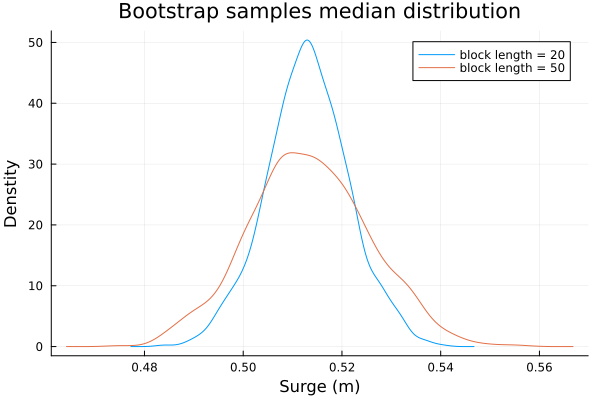

In [93]:
kernel_dist_20 = kde(reduce(vcat,rp_boot_20))
kernel_dist_50 = kde(reduce(vcat,rp_boot_50))

plot(kernel_dist_20.x,kernel_dist_20.density,label="block length = 20",title="Bootstrap samples median distribution",xlabel="Surge (m)",ylabel="Denstity")
plot!(kernel_dist_50.x,kernel_dist_50.density,label="block length = 50")



Example how a random selected bootstrap sample looks like compared to the harmonic and gauge observations

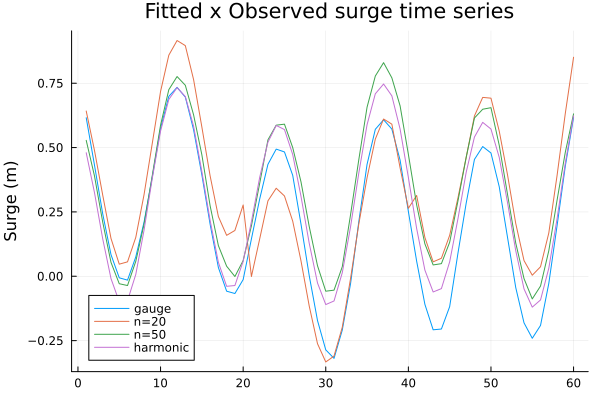

In [99]:
pos=(1:60) #.+ 100
boot=200
plot((gauge)[pos],label="gauge",title="Fitted x Observed surge time series",ylabel="Surge (m)")
plot!((boot_samps_weather_b20[:,boot])[pos],label="n=20")
plot!((boot_samps_weather_b50[:,boot])[pos],label="n=50")
plot!((harmonic)[pos],label="harmonic")